# 7. Configuration as YAML and the rompy CLI

**What this shows:** the storm-impact model from Tutorial 6 written as a YAML file,
loaded in Python and generated from the command line.

**Prerequisites:** [6. A complete storm-impact setup](06_complete_setup.ipynb).

**You will learn:**

- how Python objects map to YAML, and what `model_type` is for
- how to load, check and generate a YAML configuration in Python
- how to validate and generate it with the `rompy` command-line tool

**Data used:** the same files as Tutorial 6, referenced from
[`07_yaml_and_cli.yml`](07_yaml_and_cli.yml).

## Why YAML?

A YAML file holds the whole model in one place. It can be version-controlled, shared,
edited without Python, and run on another machine or in a pipeline. It is validated
against the same classes as the Python objects, so mistakes are caught before any
file is written.

## Setup

In [1]:
import shutil
from pathlib import Path

import yaml
from pydantic import ValidationError
from rompy.logging import config as logging_config
from rompy.model import ModelRun

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

CONFIG_FILE = Path("07_yaml_and_cli.yml")
shutil.rmtree("_output/07_yaml_and_cli", ignore_errors=True)

## 1. The YAML file

The file has the fields of a `ModelRun`: `run_id`, `output_dir` and `period`, plus
`config` holding the XBeach model. Each nested object has the same fields as its
Python class.

In [2]:
print(CONFIG_FILE.read_text())

# XBeach storm-impact model from tutorial 6, described in YAML.
#
# Generate the workspace from this folder with:
#   rompy generate 07_yaml_and_cli.yml
#
# Relative paths are resolved from the folder the command is run in.

run_id: storm_impact_yaml
output_dir: _output/07_yaml_and_cli
delete_existing: true

period:
  start: 2023-01-01T00:00
  end: 2023-01-01T12:00
  interval: 1h

config:
  model_type: xbeach

  grid:
    model_type: regular
    ori: {x: 115.594239, y: -32.641104, crs: "EPSG:4326"}
    alfa: 347.0
    dx: 10.0
    dy: 15.0
    nx: 230
    ny: 220
    crs: "EPSG:28350"

  bathy:
    model_type: xbeach_bathy
    source:
      model_type: geotiff
      filename: ../data/bathy.tif
    posdwn: false
    interpolator:
      model_type: scipy_regular_grid
      kwargs: {method: linear, fill_value: null}
    extension:
      model_type: linear
      depth: 25.0
      slope: 0.05
    left: 5
    right: 5

  input:
    wave:
      model_type: station_spectra_swan
      source:
 

Where a field accepts several classes, `model_type` names the one to use. For
example, `model_type: surfbeat` selects `Surfbeat` and `model_type: geotiff` selects
`SourceGeotiff`. Each class's `model_type` is listed in the API reference.

## 2. Load and check in Python

Loading the YAML into a `ModelRun` validates everything and builds the same objects
as in Tutorial 6.

In [3]:
conf = yaml.safe_load(CONFIG_FILE.read_text())
modelrun = ModelRun(**conf)

print(type(modelrun.config.input.wave).__name__)
print(type(modelrun.config.physics.wavemodel).__name__)

BoundaryStationSpectraSwan
Surfbeat


The objects work as if you had created them in Python, so you can inspect them before
generating anything. Here is the grid:

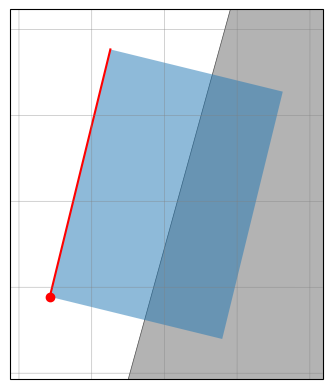

In [4]:
ax = modelrun.config.grid.plot(scale="i")

Invalid values are reported with the path to the offending field. Here a negative
friction coefficient is rejected:

In [5]:
conf["config"]["physics"]["bedfriction"]["bedfriccoef"] = -1
try:
    ModelRun(**conf)
except ValidationError as error:
    for err in error.errors():
        print(".".join(str(loc) for loc in err["loc"]), "->", err["msg"])

config.xbeach.physics.bedfriction.manning.bedfriccoef -> Input should be greater than or equal to 0


## 3. Generate from Python

Calling the `ModelRun` writes the workspace to `output_dir/run_id`.

In [6]:
workspace = Path(ModelRun(**yaml.safe_load(CONFIG_FILE.read_text()))())
sorted(p.name for p in workspace.iterdir())

['bathy.txt',
 'params.txt',
 'swan-20230101T000000.txt',
 'swan-20230101T030000.txt',
 'swan-20230101T060000.txt',
 'swan-20230101T090000.txt',
 'swan-filelist.txt',
 'tide-20230101T000000-20230101T120000.txt',
 'wind-20230101T000000-20230101T120000.txt',
 'xdata.txt',
 'ydata.txt']

## 4. The rompy command-line tool

rompy installs a `rompy` command that works directly on the YAML file, so no Python
code is needed to produce a workspace. In a notebook, the `!` prefix runs a shell
command. In a terminal, type the same command without the `!`.

`rompy validate` checks the file and exits with an error if anything is wrong:

In [7]:
!rompy validate 07_yaml_and_cli.yml && echo "Configuration is valid"

Configuration is valid


`rompy generate` writes the workspace:

In [8]:
!rompy generate 07_yaml_and_cli.yml && ls _output/07_yaml_and_cli/storm_impact_yaml

bathy.txt		  swan-filelist.txt
params.txt		  tide-20230101T000000-20230101T120000.txt
swan-20230101T000000.txt  wind-20230101T000000-20230101T120000.txt
swan-20230101T030000.txt  xdata.txt
swan-20230101T060000.txt  ydata.txt
swan-20230101T090000.txt


Other useful commands are `rompy run` (generate and run with a backend),
`rompy schema` (print the JSON schema of the configuration) and `rompy --help`.
[Running XBeach](../examples/running_xbeach.ipynb) shows how to run the workspace.

## Summary

- A YAML file mirrors the Python objects. `model_type` selects between alternatives.
- `ModelRun(**yaml.safe_load(...))` loads and validates it in Python.
- `rompy validate` and `rompy generate` do the same from the command line.

This completes the tutorial. The [examples](../README.md#examples) cover each feature
in more depth.